In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [2]:
import json
import os

In [74]:
class MemoryState(TypedDict):
    query: str
    response: str
    short_memory: List[str]
    long_memory: List[str]

In [75]:
MEMORY_FILE = "long_memory.json"
def load_long_memory():
    if os.path.exists(MEMORY_FILE):
        with open(MEMORY_FILE,"r") as f:
            return json.load(f)
    return []
def save_long_memory(memory):
    with open(MEMORY_FILE,"w") as f:
        json.dump(memory,f)

In [76]:
def recall_memory(state: MemoryState):
    long_mem = load_long_memory()
    return {"long_memory":long_mem}

In [77]:
def generate_response(state: MemoryState):
    query = state["query"].lower()
    long_mem = state.get("long_memory",[])
    if query.lower().startswith("remember"):
        fact = query.replace("remember","").strip()
        return {"response":f"I'll remember: {fact}"}

    for fact in long_mem:
        if any(word in fact.lower() for word in query.split()):
            return {"response":f"You told me: {fact}"}
        return {"response":"I don't know yet!"}

In [78]:
def save_memory(state: MemoryState):
    query = state["query"]
    if query.lower().startswith("remember"):
        fact = query.lower().replace("remember","").strip()
        long_mem = load_long_memory()
        long_mem.append(fact)
        save_long_memory(long_mem)
    short_mem = state.get("short_memory",[])
    short_mem.append(query)
    return {"short_memory":short_mem}

In [79]:
workflow = StateGraph(MemoryState)
workflow.add_node("recall",recall_memory)
workflow.add_node("respond",generate_response)
workflow.add_node("save",save_memory)
workflow.set_entry_point("recall")

In [80]:
workflow.add_edge("recall","respond")
workflow.add_edge("respond","save")
workflow.add_edge("save",END)

In [81]:
app = workflow.compile()

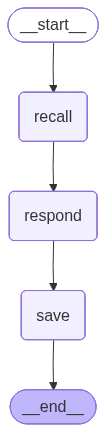

In [82]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [83]:
state = {
    "query":"",
    "short_memory":[],
    "long_memory":[]
}

In [84]:
state["query"] = "remember I am learning langgraph"
state = app.invoke(state)
print(state["response"])

I'll remember: i am learning langgraph


In [85]:
state["query"] = "what am I learning?"
state = app.invoke(state)
print(state["response"])

You told me: i am learning langgraph


In [ ]:
while True:
    user = input("You: ")

    if user.lower() == "q":
        break

    state["query"] = user
    state = app.invoke(state)

    print("Bot:", state["response"])

You:  hey


Bot: I don't know yet!


You:  My Name is Shraddha


Bot: I don't know yet!


You:  Remember my name is Shraddha


Bot: I'll remember: my name is shraddha


You:  What is my name?


Bot: I don't know yet!
